# Загрузка данных через API kaggle

In [8]:
import kaggle

In [10]:
kaggle.api.dataset_download_files(dataset = "carrie1/ecommerce-data", 
                                  path='data/', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data


# Чтение данных Pandas

In [18]:
import pandas as pd

In [99]:
df = pd.read_csv('data/data.csv', encoding='ISO-8859-1') # ISO-8859-1 - для западноевропейских языков, cp1251 - для кириллицы
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [101]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='%m/%d/%Y %H:%M')

In [103]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

# Чтение данных в SQL

In [36]:
# Импортировать модуль
import sqlite3

In [85]:
sqlite3.sqlite_version

'3.45.3'

In [39]:
# Установить соединение с файлом БД
conn = sqlite3.connect('db')

In [42]:
#Создать курсор
cur = conn.cursor()

In [45]:
# функция для вызова sql запроса
def select(sql):
  return pd.read_sql(sql,conn)

In [105]:
df.to_sql('ecommerce', conn, index=False, if_exists='replace')

541909

In [107]:
sql = ''' SELECT * FROM ecommerce LIMIT 5'''

In [109]:
select(sql)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [111]:
select(sql).dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

# Что такое RFM

- Recency (давность) — Как недавно клиент совершал покупку/взаимодействие. Чем меньше прошло времени, тем "горячее" клиент и тем выше вероятность повторного отклика.

- Frequency (частота) — Как часто клиент совершает покупки/взаимодействия за определённый период. Показывает вовлечённость.

- Monetary (денежная ценность) — Сколько денег клиент принёс за определённый период. Показывает прямую экономическую ценность.

rfm = (r + f+ m) / 3

Также сегментация клиентов
- 111
- 112
- 113

# Количество покупок по месяцам

In [117]:
sql = ''' SELECT *, DATE(InvoiceDate, 'start of month')
          FROM ecommerce
          '''

In [121]:
sql = ''' SELECT DATE(t.InvoiceDate, 'start of month'), COUNT(*)
          FROM ecommerce t
          GROUP BY DATE(t.InvoiceDate, 'start of month')
          '''

In [123]:
select(sql)

,"DATE(t.InvoiceDate, 'start of month')",COUNT(*)
0,2010-12-01,42481
1,2011-01-01,35147
2,2011-02-01,27707
3,2011-03-01,36748
4,2011-04-01,29916
5,2011-05-01,37030
6,2011-06-01,36874
7,2011-07-01,39518
8,2011-08-01,35284
9,2011-09-01,50226


# Дата регистрации клиента и вся выручка от него

In [214]:
sql = ''' SELECT MAX(InvoiceDate) FROM ecommerce'''

In [218]:
# видим, что декабрь не полностью заполнен, поэтому возьмем данные по октябрь, а проверять будем на ноябре
select(sql)

,MAX(InvoiceDate)
0,2011-12-09 12:50:00


In [220]:
sql = ''' SELECT CustomerID, MIN(t.InvoiceDate) as reg_date,
          SUM(Quantity*UnitPrice) AS revenue
          FROM ecommerce t
          WHERE DATE(t.InvoiceDate, 'start of month') <= '2011-10-01' --последний месяц не берем
          AND CustomerID IS NOT NULL --пропуски не берем
          GROUP BY CustomerID
          '''

In [222]:
select(sql)

,CustomerID,reg_date,revenue
0,12346.0,2011-01-18 10:01:00,0.00
1,12347.0,2010-12-07 14:57:00,4085.18
2,12348.0,2010-12-16 19:09:00,1797.24
3,12350.0,2011-02-02 16:01:00,334.40
4,12352.0,2011-02-16 12:33:00,1233.68
...,...,...,...
4005,18280.0,2011-03-07 09:52:00,180.60
4006,18281.0,2011-06-12 10:53:00,80.82
4007,18282.0,2011-08-05 13:35:00,98.76
4008,18283.0,2011-01-06 14:14:00,1235.32


In [224]:
t = select(sql)

<Axes: ylabel='Frequency'>

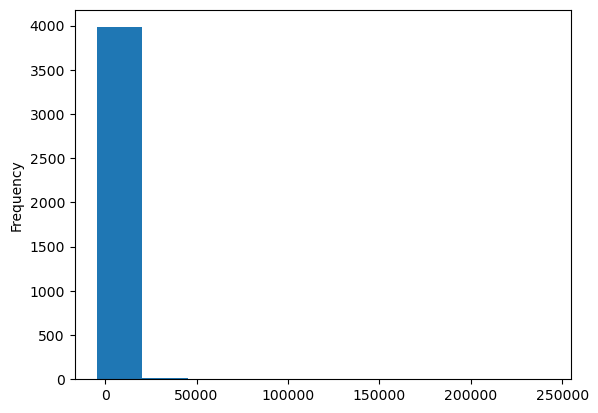

In [225]:
t['revenue'].plot(kind = 'hist')

# Фильтрация

У нас есть клиенты, которые покупают на очень большие суммы. Возможно это фирмы и их стоит считать отдельно

In [230]:
t.sort_values(by='revenue', ascending=False)

,CustomerID,reg_date,revenue
1583,14646.0,2010-12-20 10:09:00,242385.59
3885,18102.0,2010-12-07 16:42:00,229621.87
3458,17450.0,2010-12-07 09:23:00,158082.32
50,12415.0,2011-01-06 11:12:00,117807.30
1246,14156.0,2010-12-02 17:08:00,106772.32
...,...,...,...
114,12503.0,2011-01-06 11:51:00,-1126.00
3556,17603.0,2011-03-17 14:39:00,-1165.30
1283,14213.0,2010-12-03 09:47:00,-1192.20
2069,15369.0,2011-07-18 15:11:00,-1592.49


<Axes: ylabel='Frequency'>

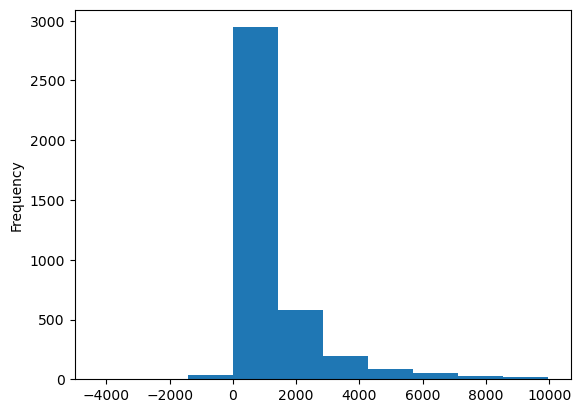

In [232]:
t[t['revenue'] <= 10000]['revenue'].plot(kind = 'hist')

In [234]:
# после фильтрации у нас остается 97,8% клиентов. Гуд
len(t[t['revenue'] <= 10000])/len(t)

0.9812967581047382

# Фильтрация в SQL

In [237]:
sql = '''
    SELECT *
    FROM
          (SELECT CustomerID, MIN(t.InvoiceDate) as reg_date,
          SUM(Quantity*UnitPrice) AS revenue
          FROM ecommerce t
          WHERE DATE(t.InvoiceDate, 'start of month') <= '2011-10-01' --последний месяц не берем
          AND CustomerID IS NOT NULL --пропуски не берем
          GROUP BY CustomerID)
    WHERE revenue < 10000
          '''

In [239]:
select(sql)

,CustomerID,reg_date,revenue
0,12346.0,2011-01-18 10:01:00,0.00
1,12347.0,2010-12-07 14:57:00,4085.18
2,12348.0,2010-12-16 19:09:00,1797.24
3,12350.0,2011-02-02 16:01:00,334.40
4,12352.0,2011-02-16 12:33:00,1233.68
...,...,...,...
3930,18280.0,2011-03-07 09:52:00,180.60
3931,18281.0,2011-06-12 10:53:00,80.82
3932,18282.0,2011-08-05 13:35:00,98.76
3933,18283.0,2011-01-06 14:14:00,1235.32


# Создание таблицы в SQL

In [298]:
sql = '''
DROP TABLE IF EXISTS customer;

CREATE TABLE customer AS 
    SELECT *
    FROM
          (SELECT CustomerID, MIN(t.InvoiceDate) as reg_date,
          SUM(Quantity*UnitPrice) AS revenue
          FROM ecommerce t
          WHERE DATE(t.InvoiceDate, 'start of month') <= '2011-10-01' --последний месяц не берем
          AND CustomerID IS NOT NULL --пропуски не берем
          GROUP BY CustomerID)
    WHERE revenue < 10000
          '''

## Выполнение скрипта через курсор

In [301]:
cur.executescript(sql)

In [287]:
sql = ''' SELECT * FROM customer LIMIT 10'''

In [289]:
select(sql)

,CustomerID,reg_date,revenue
0,12346.0,2011-01-18 10:01:00,0.00
1,12347.0,2010-12-07 14:57:00,4085.18
2,12348.0,2010-12-16 19:09:00,1797.24
3,12350.0,2011-02-02 16:01:00,334.40
4,12352.0,2011-02-16 12:33:00,1233.68
5,12353.0,2011-05-19 17:47:00,89.00
6,12354.0,2011-04-21 13:11:00,1079.40
7,12355.0,2011-05-09 13:49:00,459.40
8,12356.0,2011-01-18 09:50:00,2753.08
9,12358.0,2011-07-12 10:04:00,484.86


# Считаем метрики для RFM

1. Recency (R): Количество дней/недель/месяцев с момента последней покупки клиента до даты анализа.

Пример: Если клиент покупал что-то вчера, а анализ на 1 мая, то R = 1 день.

2. Frequency (F): Количество совершённых транзакций (или заказов) за выбранный период (например, за последний год). В нашем случае у нас есть номер заказа "InvoiceNo". В нем несколько товаров. Один заказ - это одна транзакция. Поэтому считаем число уникальных заказов (InvoiceNo) каждого пользователя
4. Monetary (M): Общая сумма всех транзакций клиента за тот же период. Иногда используют средний чек (M = Monetary / Frequency).

Выбор "момента анализа" (Snapshot Date)
Определите дату, на которую вы "снимаете" данные. Обычно это сегодняшний день или конец отчётного периода. Все расчёты будут вестись относительно этой даты. 

`Выбираем 2011-11-01`

In [344]:
sql = '''
DROP TABLE IF EXISTS customer;

CREATE TABLE customer AS 
    SELECT t1.*,
    date('2011-11-01') AS reporting_date,
    julianday(date('2011-11-01')) - julianday(t1.last_purchase_date) AS recency
    FROM
          (SELECT t.CustomerID, MIN(t.InvoiceDate) AS reg_date,
          MAX(t.InvoiceDate) AS last_purchase_date,
          SUM(t.Quantity*t.UnitPrice) AS monetary,
          COUNT(DISTINCT(t.InvoiceNo)) AS frequency
          FROM ecommerce t
          WHERE DATE(t.InvoiceDate, 'start of month') <= '2011-10-01' --последний месяц не берем
          AND t.CustomerID IS NOT NULL --пропуски не берем
          GROUP BY t.CustomerID) t1
    WHERE t1.monetary < 10000
          '''

In [346]:
cur.executescript(sql)

In [348]:
sql = ''' SELECT * FROM customer'''

In [350]:
select(sql)

,CustomerID,reg_date,last_purchase_date,monetary,frequency,reporting_date,recency
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:17:00,0.00,2,2011-11-01,286.571528
1,12347.0,2010-12-07 14:57:00,2011-10-31 12:25:00,4085.18,6,2011-11-01,0.482639
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,1797.24,4,2011-11-01,36.449306
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,334.40,1,2011-11-01,271.332639
4,12352.0,2011-02-16 12:33:00,2011-09-28 14:58:00,1233.68,10,2011-11-01,33.376389
...,...,...,...,...,...,...,...
3930,18280.0,2011-03-07 09:52:00,2011-03-07 09:52:00,180.60,1,2011-11-01,238.588889
3931,18281.0,2011-06-12 10:53:00,2011-06-12 10:53:00,80.82,1,2011-11-01,141.546528
3932,18282.0,2011-08-05 13:35:00,2011-08-09 15:10:00,98.76,2,2011-11-01,83.368056
3933,18283.0,2011-01-06 14:14:00,2011-10-27 14:38:00,1235.32,11,2011-11-01,4.390278


# Присвоение R-, F-, M-баллов

In [353]:
t = select(sql)

## Квантиль

Делим всех клиентов на группы по квантилям

Квантиль — это значение, которое делит набор данных на равные части. Простыми словами, q-й квантиль — это такое значение, ниже которого находится q доля (или процент) всех наблюдений. 

## Recency (R) - давность покупок

In [357]:
t['recency']

0       286.571528
1         0.482639
2        36.449306
3       271.332639
4        33.376389
           ...    
3930    238.588889
3931    141.546528
3932     83.368056
3933      4.390278
3934      3.604861
Name: recency, Length: 3935, dtype: float64

In [378]:
t['R'] = 5 - (pd.qcut(t['recency'], 4, labels=False) + 1)

In [380]:
t

,CustomerID,reg_date,last_purchase_date,monetary,frequency,reporting_date,recency,R
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:17:00,0.00,2,2011-11-01,286.571528,1
1,12347.0,2010-12-07 14:57:00,2011-10-31 12:25:00,4085.18,6,2011-11-01,0.482639,4
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,1797.24,4,2011-11-01,36.449306,3
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,334.40,1,2011-11-01,271.332639,1
4,12352.0,2011-02-16 12:33:00,2011-09-28 14:58:00,1233.68,10,2011-11-01,33.376389,3
...,...,...,...,...,...,...,...,...
3930,18280.0,2011-03-07 09:52:00,2011-03-07 09:52:00,180.60,1,2011-11-01,238.588889,1
3931,18281.0,2011-06-12 10:53:00,2011-06-12 10:53:00,80.82,1,2011-11-01,141.546528,2
3932,18282.0,2011-08-05 13:35:00,2011-08-09 15:10:00,98.76,2,2011-11-01,83.368056,2
3933,18283.0,2011-01-06 14:14:00,2011-10-27 14:38:00,1235.32,11,2011-11-01,4.390278,4


In [382]:
t.groupby('R')['recency'].agg(['mean', 'count'])

,mean,count
R,,
1,238.929315,984
2,97.578577,983
3,34.175226,984
4,9.272108,984


## Frequency (F) - частота покупок

Проблема - много одинаковых значений, из-за которых не получается разбить на равные группы

### Автоматический расчет

In [390]:
t['F'] = pd.qcut(t['frequency'], 4, labels=False, duplicates='drop') + 1

In [392]:
t.groupby('F')['frequency'].agg(['mean', 'count'])

,mean,count
F,,
1,1.367202,2116
2,3.808654,1040
3,10.928113,779


In [396]:
t.groupby('F')['frequency'].agg(set)

F
1                                               {1, 2}
2                                            {3, 4, 5}
3    {6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 1...
Name: frequency, dtype: object

### Ручной расчет

In [401]:
t['frequency'].value_counts()

frequency
1     1339
2      777
3      461
4      317
5      262
6      152
7      115
8       96
9       66
10      62
11      55
13      34
12      33
14      27
15      21
16      20
17      13
19      10
20       9
24       9
18       8
21       8
25       7
23       6
22       5
26       4
28       3
31       3
40       2
35       2
38       2
34       1
74       1
29       1
27       1
76       1
33       1
36       1
Name: count, dtype: int64

In [419]:
def get_F(row):
    if row == 1:
        return 1
    if row in [2,3]:
        return 2
    if row in [3,4,5,6]:
        return 3 
    else:
        return 4

In [421]:
t['F'] = t['frequency'].apply(get_F)

In [423]:
t.groupby('F')['frequency'].agg(['mean', 'count'])

,mean,count
F,,
1,1.000000,1339
2,2.372375,1238
3,4.774282,731
4,12.122807,627


## Monetary (M) - сумма покупок

In [426]:
t['M'] = pd.qcut(t['monetary'], 4, labels=False) + 1

In [428]:
t

,CustomerID,reg_date,last_purchase_date,monetary,frequency,reporting_date,recency,R,F,M
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:17:00,0.00,2,2011-11-01,286.571528,1,2,1
1,12347.0,2010-12-07 14:57:00,2011-10-31 12:25:00,4085.18,6,2011-11-01,0.482639,4,3,4
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,1797.24,4,2011-11-01,36.449306,3,3,4
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,334.40,1,2011-11-01,271.332639,1,1,2
4,12352.0,2011-02-16 12:33:00,2011-09-28 14:58:00,1233.68,10,2011-11-01,33.376389,3,4,3
...,...,...,...,...,...,...,...,...,...,...
3930,18280.0,2011-03-07 09:52:00,2011-03-07 09:52:00,180.60,1,2011-11-01,238.588889,1,1,1
3931,18281.0,2011-06-12 10:53:00,2011-06-12 10:53:00,80.82,1,2011-11-01,141.546528,2,1,1
3932,18282.0,2011-08-05 13:35:00,2011-08-09 15:10:00,98.76,2,2011-11-01,83.368056,2,2,1
3933,18283.0,2011-01-06 14:14:00,2011-10-27 14:38:00,1235.32,11,2011-11-01,4.390278,4,4,3


In [430]:
t.groupby('M')['monetary'].agg(['mean', 'count'])

,mean,count
M,,
1,138.807317,984
2,401.886477,984
3,894.042645,983
4,3012.871109,984


# Считаем RFM-score

In [442]:
t['rfm_score'] = (t['R'] + t['F'] + t['M'])/3

In [450]:
t.sort_values(by='rfm_score', ascending=False)

,CustomerID,reg_date,last_purchase_date,monetary,frequency,reporting_date,recency,R,F,M,rfm_score
1172,14085.0,2010-12-06 12:39:00,2011-10-25 16:20:00,3525.98,15,2011-11-01,6.319444,4,4,4,4.0
1187,14112.0,2011-03-09 11:28:00,2011-10-30 16:00:00,2613.15,10,2011-11-01,1.333333,4,4,4,4.0
2113,15505.0,2011-07-07 13:33:00,2011-10-18 07:56:00,3497.14,7,2011-11-01,13.669444,4,4,4,4.0
2098,15482.0,2010-12-16 10:08:00,2011-10-25 17:32:00,2503.50,8,2011-11-01,6.269444,4,4,4,4.0
3337,17365.0,2011-01-11 12:11:00,2011-10-20 12:07:00,4375.19,7,2011-11-01,11.495139,4,4,4,4.0
...,...,...,...,...,...,...,...,...,...,...,...
2475,16061.0,2011-03-15 14:41:00,2011-03-15 14:41:00,-29.95,1,2011-11-01,230.388194,1,1,1,1.0
3533,17670.0,2011-04-26 09:12:00,2011-04-26 09:12:00,205.70,1,2011-11-01,188.616667,1,1,1,1.0
2484,16078.0,2011-03-01 09:47:00,2011-03-01 09:47:00,79.20,1,2011-11-01,244.592361,1,1,1,1.0
2497,16097.0,2011-04-13 13:47:00,2011-04-13 13:47:00,185.05,1,2011-11-01,201.425694,1,1,1,1.0


# RFM сегментация

In [484]:
t.drop('RFM_score', axis = 1, inplace=True)

In [486]:
t['RFM_Score'] = t['R'] + t['F'] + t['M']

In [488]:
def rfm_level(df):
    if df['RFM_Score'] >= 9:
        return 'Can\'t Loose Them'
    elif ((df['RFM_Score'] >= 8) and (df['RFM_Score'] < 9)):
        return 'Champions'
    elif ((df['RFM_Score'] >= 7) and (df['RFM_Score'] < 8)):
        return 'Loyal'
    elif ((df['RFM_Score'] >= 6) and (df['RFM_Score'] < 7)):
        return 'Potential'
    elif ((df['RFM_Score'] >= 5) and (df['RFM_Score'] < 6)):
        return 'Promising'
    elif ((df['RFM_Score'] >= 4) and (df['RFM_Score'] < 5)):
        return 'Needs Attention'
    else:
        return 'Require Activation'

In [494]:
t['segment'] = t.apply(rfm_level, axis=1)

In [496]:
t

,CustomerID,reg_date,last_purchase_date,monetary,frequency,reporting_date,recency,R,F,M,rfm_score,RFM_Score,segment
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:17:00,0.00,2,2011-11-01,286.571528,1,2,1,1.333333,4,Needs Attention
1,12347.0,2010-12-07 14:57:00,2011-10-31 12:25:00,4085.18,6,2011-11-01,0.482639,4,3,4,3.666667,11,Can't Loose Them
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,1797.24,4,2011-11-01,36.449306,3,3,4,3.333333,10,Can't Loose Them
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,334.40,1,2011-11-01,271.332639,1,1,2,1.333333,4,Needs Attention
4,12352.0,2011-02-16 12:33:00,2011-09-28 14:58:00,1233.68,10,2011-11-01,33.376389,3,4,3,3.333333,10,Can't Loose Them
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3930,18280.0,2011-03-07 09:52:00,2011-03-07 09:52:00,180.60,1,2011-11-01,238.588889,1,1,1,1.000000,3,Require Activation
3931,18281.0,2011-06-12 10:53:00,2011-06-12 10:53:00,80.82,1,2011-11-01,141.546528,2,1,1,1.333333,4,Needs Attention
3932,18282.0,2011-08-05 13:35:00,2011-08-09 15:10:00,98.76,2,2011-11-01,83.368056,2,2,1,1.666667,5,Promising
3933,18283.0,2011-01-06 14:14:00,2011-10-27 14:38:00,1235.32,11,2011-11-01,4.390278,4,4,3,3.666667,11,Can't Loose Them


In [498]:
t.groupby('segment')['monetary'].agg(['mean', 'count'])

,mean,count
segment,,
Can't Loose Them,2399.799870,1307
Champions,979.344811,418
Loyal,656.788071,476
Needs Attention,230.661849,438
Potential,456.758162,500
Promising,332.846186,409
Require Activation,133.005271,387


# Обобщение

Процентиль (перцентиль) — статистический показатель, который указывает на относительное положение значения в наборе данных. Это значение, ниже которого находится определённый процент всех наблюдений.
Например:
- 50-й процентиль — это оценка, на которую приходится 50% оценок в распределении. 
- 95-й процентиль — это рост того школьника, который выше 95% других школьников из 100.
- Если время отклика API составляет 100 мс в 95-м процентиле, это означает, что 95% всех запросов выполняются быстрее 100 мс, а оставшиеся 5% — медленнее. 

# Решение на SQL

In [519]:
sql = ''' SELECT t.*,
          ntile(4) over (order by recency desc) as r,
          ntile(4) over (order by monetary asc) as m
          FROM customer t
'''

In [521]:
select(sql)

,CustomerID,reg_date,last_purchase_date,monetary,frequency,reporting_date,recency,r,m
0,18074.0,2010-12-01 09:53:00,2010-12-01 09:53:00,489.60,1,2011-11-01,334.588194,1,2
1,13747.0,2010-12-01 10:37:00,2010-12-01 10:37:00,79.60,1,2011-11-01,334.557639,1,1
2,12791.0,2010-12-01 11:27:00,2010-12-01 11:27:00,192.60,1,2011-11-01,334.522917,1,1
3,17908.0,2010-12-01 11:45:00,2010-12-01 11:45:00,243.28,1,2011-11-01,334.510417,1,1
4,12838.0,2010-12-01 11:57:00,2010-12-01 11:57:00,390.79,1,2011-11-01,334.502083,1,2
...,...,...,...,...,...,...,...,...,...
3930,15329.0,2010-12-09 15:43:00,2011-10-31 15:36:00,1032.00,4,2011-11-01,0.350000,4,3
3931,12417.0,2010-12-17 11:51:00,2011-10-31 16:02:00,3229.02,10,2011-11-01,0.331944,4,4
3932,15977.0,2011-10-31 16:24:00,2011-10-31 16:24:00,355.63,1,2011-11-01,0.316667,4,2
3933,13982.0,2010-12-09 13:57:00,2011-10-31 16:24:00,1861.11,5,2011-11-01,0.316667,4,4
